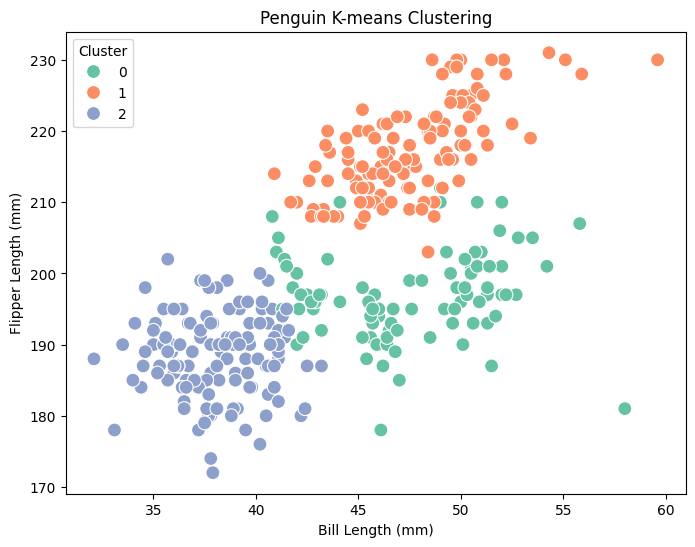

In [1]:
# 필요한 라이브러리 불러오기
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. 펭귄 데이터 불러오기
df = sns.load_dataset("penguins")

# 2. 사용할 변수 선택
# 수치형 변수만 사용
X = df[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]

# 3. 결측치 제거
X = X.dropna()

# 4. 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. K-means 클러스터링 수행
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 6. 결과를 데이터프레임에 추가
df_cluster = X.copy()
df_cluster["cluster"] = clusters

# 7. 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_cluster,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="cluster",
    palette="Set2",
    s=100
)

plt.title("Penguin K-means Clustering")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Flipper Length (mm)")
plt.legend(title="Cluster")
plt.show()

cluster  species  
0        Adelie        24
         Chinstrap     63
1        Gentoo       123
2        Adelie       127
         Chinstrap      5
dtype: int64


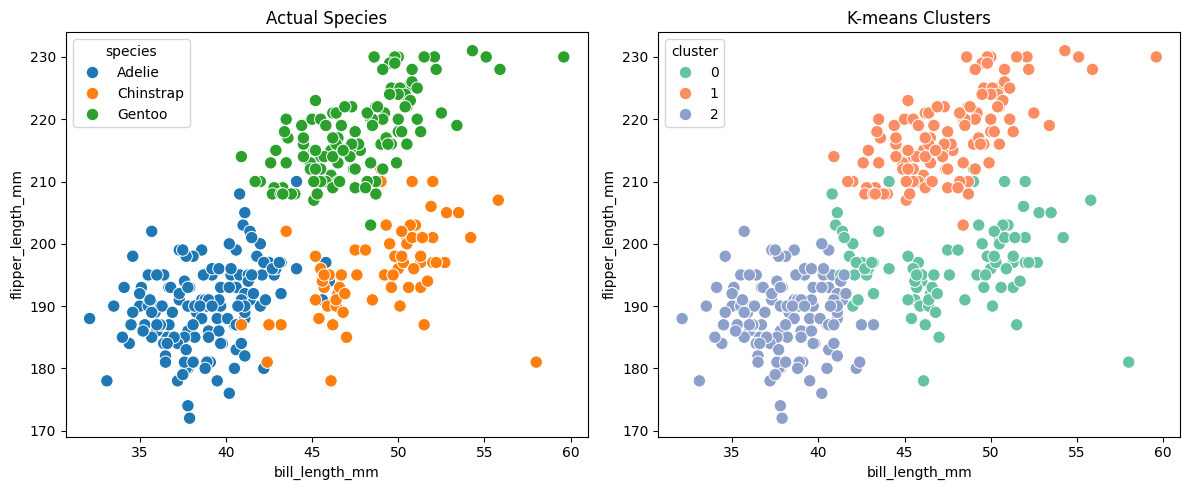

In [2]:
# species 정보까지 포함해서 비교
df2 = sns.load_dataset("penguins")
df2 = df2[["species", "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]].dropna()

X = df2[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df2["cluster"] = kmeans.fit_predict(X_scaled)

# 클러스터별 개수 보기
print(df2.groupby(["cluster", "species"]).size())

# 실제 species 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df2,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    s=80
)
plt.title("Actual Species")

plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df2,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="cluster",
    palette="Set2",
    s=80
)
plt.title("K-means Clusters")

plt.tight_layout()
plt.show()

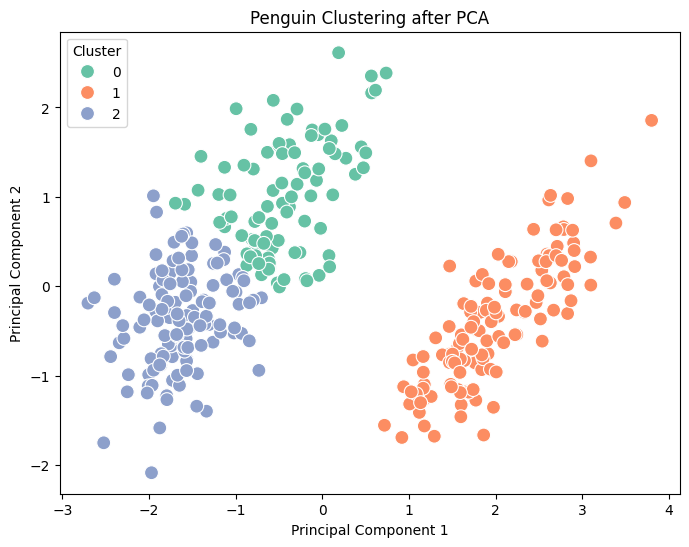

설명분산비율: [0.68843878 0.19312919]
누적 설명분산비율: 0.8815679694372629


In [3]:
# 필요한 라이브러리 불러오기
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. 펭귄 데이터 불러오기
df = sns.load_dataset("penguins")

# 2. 사용할 변수 선택
features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
X = df[features].dropna()

# 3. 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. PCA로 2차원 축소
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 5. K-means 클러스터링
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# 6. 결과 데이터프레임 만들기
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_pca["cluster"] = clusters

# 7. 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=100
)

plt.title("Penguin Clustering after PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

# 8. 설명분산비율 확인
print("설명분산비율:", pca.explained_variance_ratio_)
print("누적 설명분산비율:", pca.explained_variance_ratio_.sum())

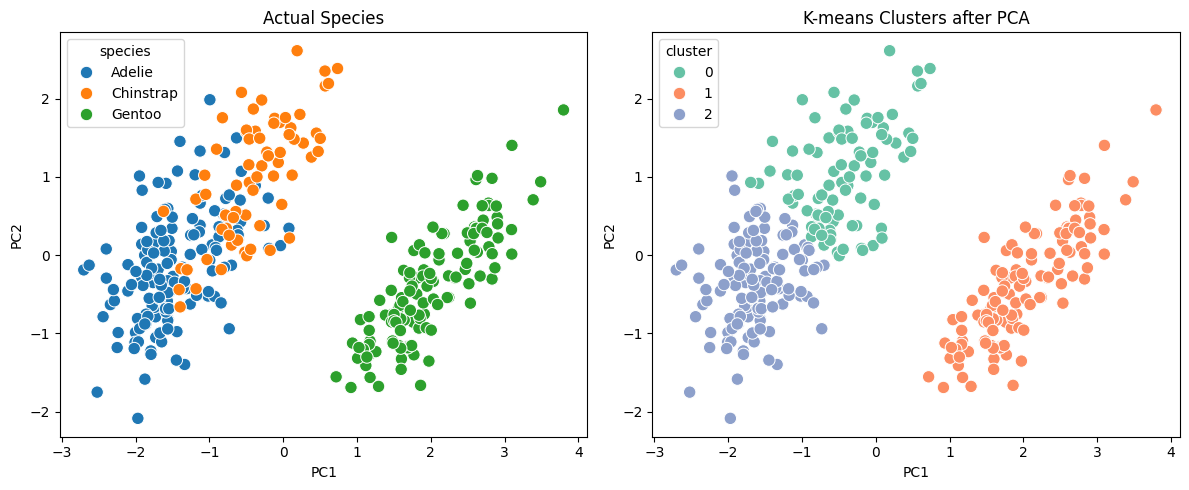

설명분산비율: [0.68843878 0.19312919]
누적 설명분산비율: 0.8815679694372629


In [4]:
# 필요한 라이브러리 불러오기
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# 1. 데이터 불러오기
df = sns.load_dataset("penguins")

# 2. 필요한 열 선택 후 결측치 제거
df2 = df[["species", "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]].dropna()

X = df2[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]

# 3. 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 5. K-means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df2["cluster"] = kmeans.fit_predict(X_pca)

# 6. PCA 결과 저장
df2["PC1"] = X_pca[:, 0]
df2["PC2"] = X_pca[:, 1]

# 7. 비교 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(
    data=df2,
    x="PC1",
    y="PC2",
    hue="species",
    s=80
)
plt.title("Actual Species")

plt.subplot(1, 2, 2)
sns.scatterplot(
    data=df2,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    s=80
)
plt.title("K-means Clusters after PCA")

plt.tight_layout()
plt.show()

# 설명분산비율 출력
print("설명분산비율:", pca.explained_variance_ratio_)
print("누적 설명분산비율:", pca.explained_variance_ratio_.sum())

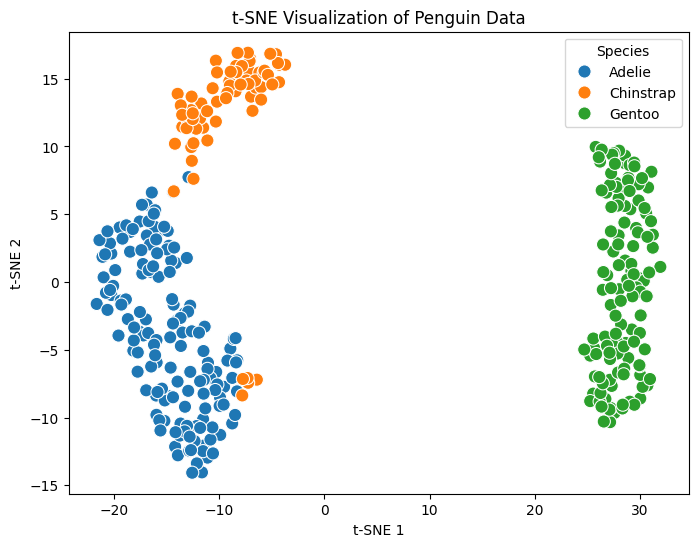

In [5]:
# 필요한 라이브러리 불러오기
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

# 1. 데이터 불러오기
df = sns.load_dataset("penguins")

# 2. 필요한 변수 선택
df2 = df[["species", "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]].dropna()

X = df2[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]

# 3. 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. t-SNE 적용
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# 5. 결과 저장
df2["TSNE1"] = X_tsne[:, 0]
df2["TSNE2"] = X_tsne[:, 1]

# 6. 시각화
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df2,
    x="TSNE1",
    y="TSNE2",
    hue="species",
    s=90
)

plt.title("t-SNE Visualization of Penguin Data")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(title="Species")
plt.show()

In [6]:
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA

# 1. 데이터 불러오기 (얼굴 이미지)
faces = fetch_olivetti_faces()
X = faces.data   # (400, 4096)
images = faces.images

print(X.shape)  # (샘플 수, 픽셀 수)

# 2. PCA 적용
pca = PCA(n_components=100, whiten=True, random_state=42)
X_pca = pca.fit_transform(X)

print("변환 후 shape:", X_pca.shape)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
(400, 4096)
변환 후 shape: (400, 100)


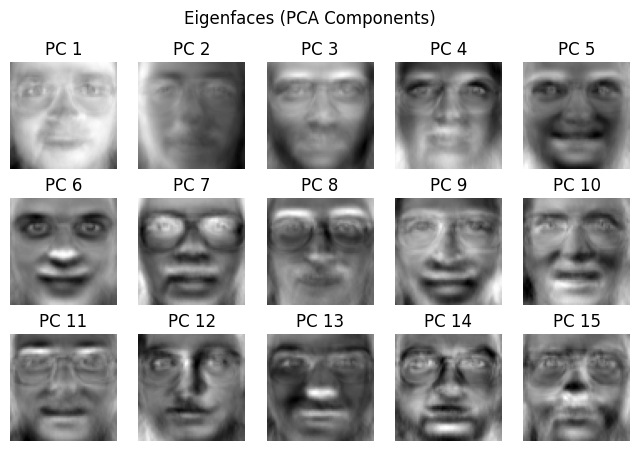

In [7]:
# PCA의 주성분(=Eigenface) 시각화
fig, axes = plt.subplots(3, 5, figsize=(8, 5))

for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(64, 64), cmap="gray")
    ax.set_title(f"PC {i+1}")
    ax.axis("off")

plt.suptitle("Eigenfaces (PCA Components)")
plt.show()

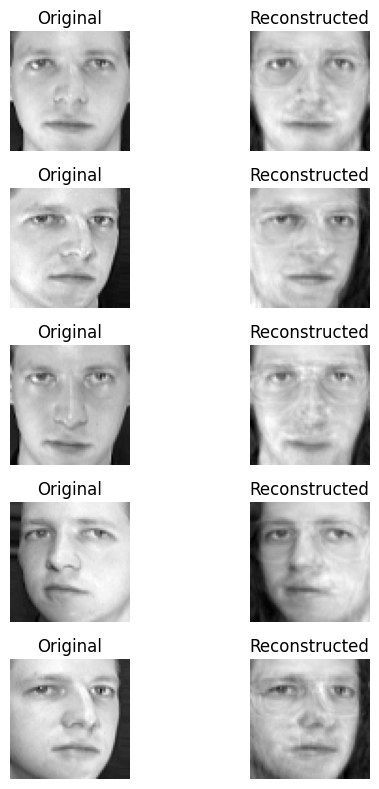

In [8]:
# 일부 얼굴 선택
n = 5
original = X[:n]

# PCA로 축소 후 복원
reconstructed = pca.inverse_transform(X_pca[:n])

# 시각화
fig, axes = plt.subplots(n, 2, figsize=(6, 8))

for i in range(n):
    # 원본
    axes[i, 0].imshow(original[i].reshape(64, 64), cmap="gray")
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    # 복원
    axes[i, 1].imshow(reconstructed[i].reshape(64, 64), cmap="gray")
    axes[i, 1].set_title("Reconstructed")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

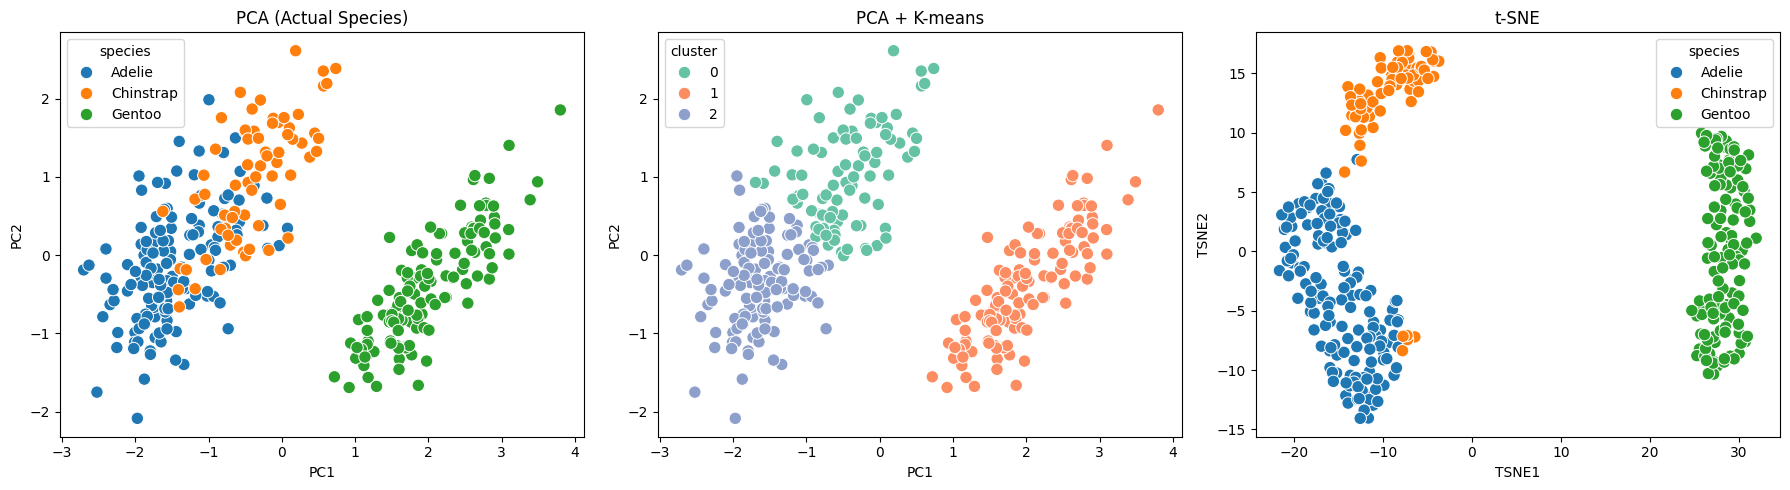

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

# 1. 데이터 불러오기
df = sns.load_dataset("penguins")

df2 = df[["species", "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]].dropna()

X = df2[["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]]

# 2. 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df2["PC1"] = X_pca[:, 0]
df2["PC2"] = X_pca[:, 1]

# 4. K-means (PCA 결과로 수행)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df2["cluster"] = kmeans.fit_predict(X_pca)

# 5. t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)
df2["TSNE1"] = X_tsne[:, 0]
df2["TSNE2"] = X_tsne[:, 1]

# 6. 시각화
plt.figure(figsize=(18, 5))

# (1) PCA + 실제 species
plt.subplot(1, 3, 1)
sns.scatterplot(data=df2, x="PC1", y="PC2", hue="species", s=80)
plt.title("PCA (Actual Species)")

# (2) PCA + K-means 결과
plt.subplot(1, 3, 2)
sns.scatterplot(data=df2, x="PC1", y="PC2", hue="cluster", palette="Set2", s=80)
plt.title("PCA + K-means")

# (3) t-SNE + 실제 species
plt.subplot(1, 3, 3)
sns.scatterplot(data=df2, x="TSNE1", y="TSNE2", hue="species", s=80)
plt.title("t-SNE")

plt.tight_layout()
plt.show()